R2= 0.978699644265237


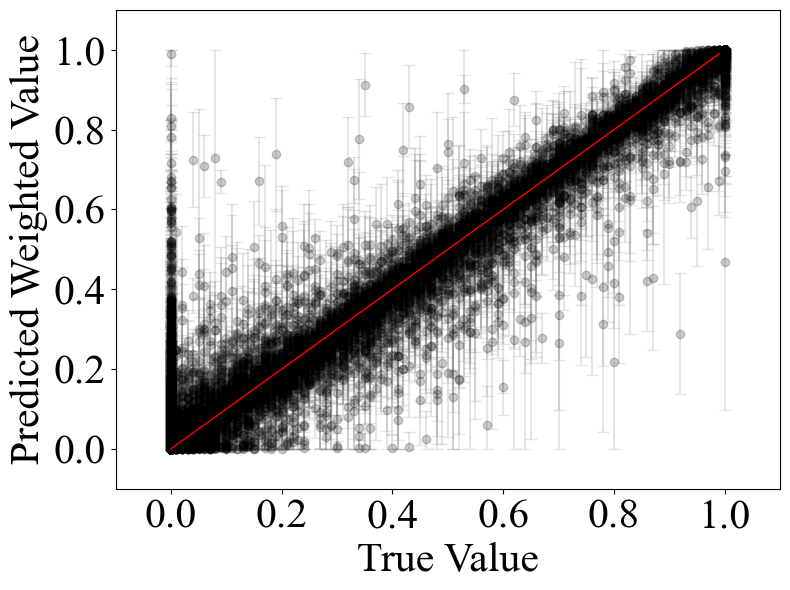

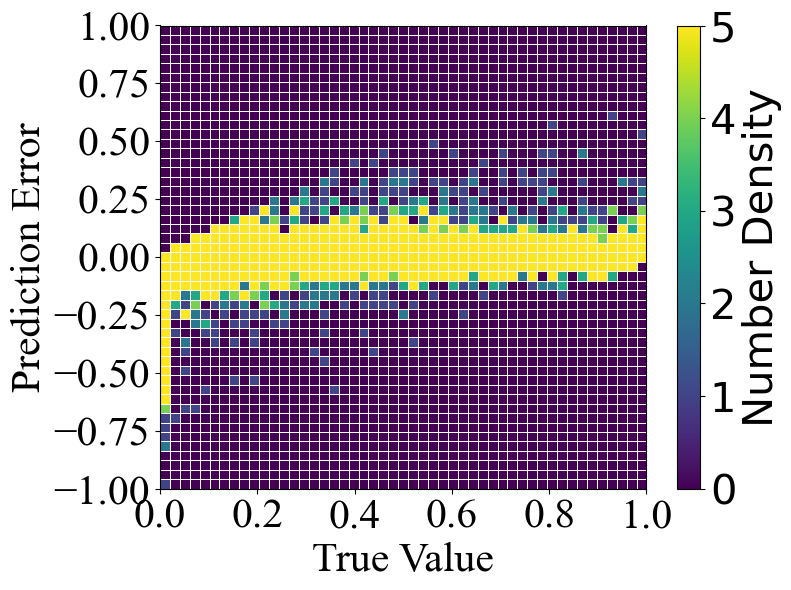

In [34]:
#This code generates figure 3 and 4 of the mansucript as well as Figure S2.

import numpy as np
import torch
import torch.optim as optim
import logging
import matplotlib.pyplot as plt
from argparse import ArgumentParser
from torch.autograd import Variable
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.distributions import Normal, OneHotCategorical
import torch.nn.utils as nn_utils
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(123456)
np.random.seed(123456)


def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0.0)        
class MDN(nn.Module):
    def __init__(self, n_hidden, n_gaussians,n_hidden_layers,bn, dout, dout_value):
        super(MDN, self).__init__()                
        layers = [nn.Linear(41, n_hidden), nn.Tanh()] # 41 = Input features
        if bn == 1:
            layers.append(nn.BatchNorm1d(n_hidden))    
        for _ in range(n_hidden_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())
        if dout==1:
            layers.append(nn.Dropout(dout_value))
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())   
        else:
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())       
        self.z_h = nn.Sequential(*layers)                        
        self.z_pi = nn.Linear(n_hidden, n_gaussians)
        self.z_sigma = nn.Linear(n_hidden, n_gaussians)
        self.z_mu = nn.Linear(n_hidden, n_gaussians)  
    def forward(self, x):
        z_h = self.z_h(x)
        pi = nn.functional.softmax(self.z_pi(z_h), -1)
        sigma = torch.exp(self.z_sigma(z_h))+ 1e-8
        sigma = torch.clamp(sigma, min=1e-4)
        mu = 0 + (1 - 0) * (torch.tanh(self.z_mu(z_h)) + 1) / 2
        return pi, sigma, mu    
oneDivSqrtTwoPI = 1.0 / np.sqrt(2.0*np.pi) 
def gaussian_distribution(y, mu, sigma):
    result = (y.expand_as(mu) - mu) * torch.reciprocal(sigma)
    result = -0.5 * (result * result)
    return (torch.exp(result) * torch.reciprocal(sigma)) * oneDivSqrtTwoPI
def mdn_loss_fn(pi, sigma, mu, y):
    result = gaussian_distribution(y, mu, sigma) * pi
    result1 = torch.sum(result, dim=1)
    result2 = -torch.log(result1+1e-12)
    return torch.mean(result2)

#---------------Chosen artitecture-----------
#model = MDN(n_hidden=55, n_gaussians=5,n_hidden_layers=7,bn=0, dout=0, dout_value=0.44976) #FCC (our)
#model = MDN(n_hidden=72, n_gaussians=5,n_hidden_layers=7,bn=0, dout=0, dout_value=0.38857) #FCC (balanced RO )
#model = MDN(n_hidden=45, n_gaussians=6,n_hidden_layers=9,bn=0, dout=1, dout_value=0.20525) #FCC (Extreme RO)
#model = MDN(n_hidden=85, n_gaussians=4,n_hidden_layers=7,bn=0, dout=0, dout_value=0.49138) #FCC (SMOTER)
#model = MDN(n_hidden=85, n_gaussians=4,n_hidden_layers=7,bn=0, dout=0, dout_value=0.49138) #FCC (Gaussian)
#model = MDN(n_hidden=99, n_gaussians=2,n_hidden_layers=6,bn=0, dout=0, dout_value=0.32939) #FCC (WERCS)

#model = MDN(n_hidden=55, n_gaussians=5,n_hidden_layers=7,bn=0, dout=0, dout_value=0.44976) #FCC
#model = MDN(n_hidden=83, n_gaussians=4,n_hidden_layers=7,bn=0, dout=0, dout_value=0.35831) #BCC
##model = MDN(n_hidden=88, n_gaussians=5,n_hidden_layers=6,bn=1, dout=1, dout_value=0.34913) #HCP
#model = MDN(n_hidden=70, n_gaussians=3,n_hidden_layers=8,bn=0, dout=0, dout_value=0.24734) #Laves
#model = MDN(n_hidden=92, n_gaussians=5,n_hidden_layers=6,bn=1, dout=0, dout_value=0.24518) #Sigma
#model = MDN(n_hidden=72, n_gaussians=5,n_hidden_layers=7,bn=0, dout=0, dout_value=0.38857) #Heusler
##model = MDN(n_hidden=72, n_gaussians=5,n_hidden_layers=7,bn=0, dout=0, dout_value=0.38857) #Liquid
model = MDN(n_hidden=91, n_gaussians=2,n_hidden_layers=6,bn=0, dout=0, dout_value=0.21738) #Other

#model = MDN(n_hidden=91, n_gaussians=2,n_hidden_layers=6,bn=0, dout=0, dout_value=0.21738) #BCC Ti-free
#model = MDN(n_hidden=72, n_gaussians=5,n_hidden_layers=7,bn=0, dout=0, dout_value=0.38857) #BCC Split
#--------------------------------------------

model.eval()
optimizer = optim.Adam(model.parameters(), lr=0.00007)
PATH = "checkpoint/model-30_other.pt" #This should be updated based on the phase of interest. The final checkpoint for all phases is uploaded in "checkpoint" folder
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


data_x = np.load('xlo_test.npy')[:,:]
data_y = np.load('ylo_test.npy')
phs=7 #Phase of interest ( fcc = 0, bcc = 1, Laves = 4, Sigma = 5, Heusler = 6, Liquid = 7)
data_y[:,1]=data_y[:,1]+data_y[:,3] 
data_y[:,7]=data_y[:,7]+data_y[:,2] 
data_x_np = torch.tensor(data_x, dtype=torch.float)
data_y_np = torch.tensor(data_y, dtype=torch.float)[:,phs:phs+1]  
pi_variable, sigma_variable, mu_variable = model(data_x_np)
loss = mdn_loss_fn(pi_variable, sigma_variable, mu_variable, data_y_np)
weighted_average_mu = torch.sum(pi_variable * mu_variable, dim=-1)
weighted_sigma = torch.sqrt(torch.sum(pi_variable * (sigma_variable ** 2 + (mu_variable - weighted_average_mu.unsqueeze(-1)) ** 2), dim=-1))
weighted_average_mu_np = weighted_average_mu.detach().numpy()
weighted_sigma_np = weighted_sigma.detach().numpy()
data_y_np = data_y_np.detach().numpy()

lower_error = np.zeros_like(weighted_average_mu_np)
upper_error=np.zeros_like(weighted_average_mu_np)
for i in range(len(weighted_average_mu_np)):
    lower_bound = weighted_average_mu_np[i] - weighted_sigma_np[i]
    upper_bound = weighted_average_mu_np[i] + weighted_sigma_np[i]    
    lower_error[i] = min(weighted_sigma_np[i], weighted_average_mu_np[i]) if lower_bound < 0 else weighted_sigma_np[i] 
    upper_error[i] = min(weighted_sigma_np[i], 1 - weighted_average_mu_np[i]) if upper_bound > 1 else weighted_sigma_np[i]    
yerr = [np.abs(lower_error),np.abs(upper_error) ] 
#yerr = weighted_sigma_np #without clamping

plt.figure(figsize=(8, 6))
plt.errorbar(data_y_np, weighted_average_mu_np, yerr=yerr, fmt='o', ecolor='gray', color='black',alpha=0.2, capsize=4)
plt.xlabel('True Value',fontsize=30, fontname='Times New Roman')
plt.ylabel('Predicted Weighted Value',fontsize=30, fontname='Times New Roman')
x = np.arange(0, 1, 0.01)
plt.plot(x, x, color='red', linewidth=1, zorder=5)
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])
plt.xticks(fontsize=30, fontname='Times New Roman')
plt.yticks(fontsize=30, fontname='Times New Roman') 
plt.tight_layout()
plt.savefig('6b.png', dpi=600)
print('R2=',r2_score(data_y_np, weighted_average_mu_np))

np.random.seed(42)
true = data_y_np[:, 0]
pred = weighted_average_mu_np[:]  
metric = (true - pred)  
x_bins = np.linspace(0, 1, 50)  
y_bins = np.linspace(-1, 1, 50)
H, x_edges, y_edges = np.histogram2d(true, metric, bins=[x_bins, y_bins])
plt.figure(figsize=(8, 6))
plt.pcolormesh(
    x_edges, 
    y_edges, 
    H.T, 
    cmap="viridis", 
    edgecolors="white",  
    linewidth=0.5,
    vmin=0, 
    vmax=5
)
cbar=plt.colorbar(label="Number Density")
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Number Density", fontsize=30)
plt.xlabel("True Value",fontsize=30, fontname='Times New Roman')
plt.ylabel("Prediction Error",fontsize=30, fontname='Times New Roman')
plt.xticks(fontsize=30, fontname='Times New Roman')
plt.yticks(fontsize=30, fontname='Times New Roman') 
plt.tight_layout()
plt.savefig('5f.png', dpi=600)


In [17]:
#Revision: This code calculate NLL following the first code of this notebook for table 1
data_y_np = torch.tensor(data_y, dtype=torch.float)[:,phs:phs+1]  
loss = mdn_loss_fn(pi_variable, sigma_variable, mu_variable, data_y_np)
print('NLL=',loss)

NLL= tensor(-6.7982, grad_fn=<MeanBackward0>)


In [18]:
#Revision: This code calculate CP following the first code of this notebook for table 1

import numpy as np
from scipy.stats import norm

pi = pi_variable.detach().cpu().numpy()
mu_k = mu_variable.detach().cpu().numpy()
sigma_k = sigma_variable.detach().cpu().numpy()
y_true = data_y_np.cpu().numpy().squeeze()

def mixture_quantile(q, pi_i, mu_i, sigma_i, tol=1e-6, max_iter=100):
    low = np.min(mu_i - 5 * sigma_i)
    high = np.max(mu_i + 5 * sigma_i)
    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        cdf_mid = np.sum(pi_i * norm.cdf((mid - mu_i) / sigma_i))
        if cdf_mid < q:
            low = mid
        else:
            high = mid
        if abs(high - low) < tol:
            break
    return 0.5 * (low + high)

lower = np.zeros(len(y_true))
upper = np.zeros(len(y_true))
for i in range(len(y_true)):
    lower[i] = mixture_quantile(0.05, pi[i], mu_k[i], sigma_k[i]) #Note: This is the value for each point such that 5% of predicted probability is below it
    upper[i] = mixture_quantile(0.95, pi[i], mu_k[i], sigma_k[i])
inside = (y_true >= lower) & (y_true <= upper)
CP = np.mean(inside)
print("CP (90% interval):", CP)

CP (90% interval): 0.9577118539024088


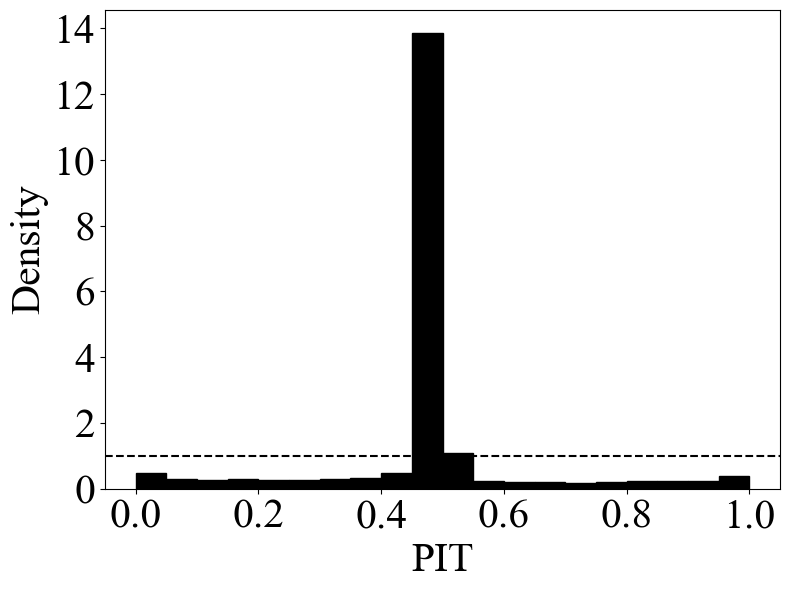

In [19]:
#Revision: This code calculate PIT following the first code of this notebook to prepare Figure 6

from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

pi = pi_variable.detach().cpu().numpy()
mu_k = mu_variable.detach().cpu().numpy()
sigma_k = sigma_variable.detach().cpu().numpy()
y_true = data_y_np.squeeze()
y_exp = y_true[:, None]


cdf_components = norm.cdf((y_exp - mu_k) / sigma_k) #Note: CDF shows what fraction of probability is ≤ y. For example, F(5)=0.8 means that 80% of outcomes are bellow 5   
pit = np.sum(pi * cdf_components, axis=1)  

plt.figure(figsize=(8, 6))
plt.hist(pit, bins=20, density=True, edgecolor='k',color='black')
plt.axhline(1.0, linestyle='--',color='black')  
plt.xlabel("PIT",fontsize=30, fontname='Times New Roman')
plt.ylabel("Density",fontsize=30, fontname='Times New Roman')
plt.xticks(fontsize=30, fontname='Times New Roman')
plt.yticks(fontsize=30, fontname='Times New Roman') 
plt.tight_layout()
plt.savefig('6e.png', dpi=600)

0.9799798486893233

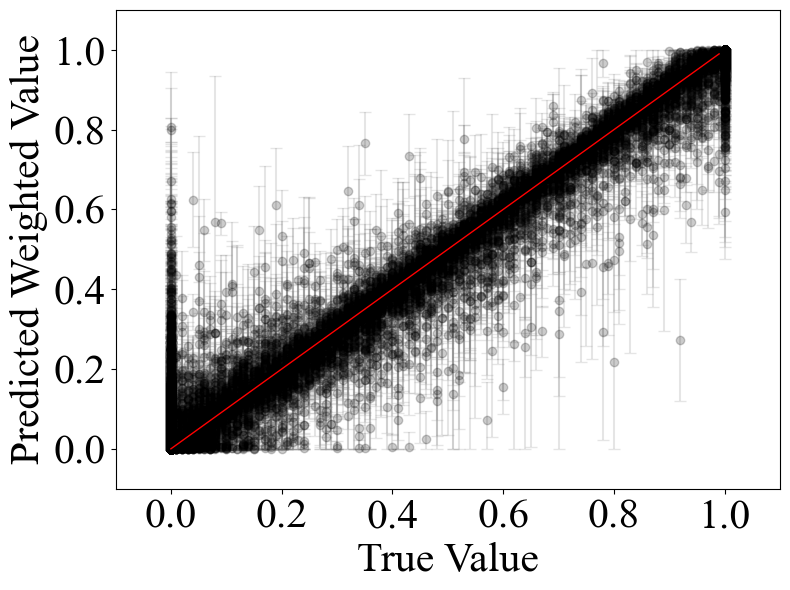

In [43]:
#This code is used to prepare Figure S3 with the first 4 # lines should be executed following first code of this notebook
#to get 0.npy, ..., 7.npy per each phase. These .npy files are the weighted mean and std predicted phase fractions.

import numpy as np
import torch
import torch.optim as optim
import logging
import matplotlib.pyplot as plt
from argparse import ArgumentParser
from torch.autograd import Variable
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.distributions import Normal, OneHotCategorical
import torch.nn.utils as nn_utils
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(123456)
np.random.seed(123456)

# Z=[]
# Z=np.append(weighted_average_mu_np.reshape(-1,1),weighted_sigma_np.reshape(-1,1),axis=1)
# with open('7.npy','wb') as f:
#     np.save(f,Z)

p0=np.load('0.npy') 
p1=np.load('1.npy')
p4=np.load('4.npy')
p5=np.load('5.npy')
p6=np.load('6.npy') 
p7=np.load('7.npy') 

for i in range(p1.shape[0]):
    p0[i,0]=p0[i,0]/(p0[i,0]+p1[i,0]+p4[i,0]+p5[i,0]+p6[i,0]+p7[i,0])
    p1[i,0]=p1[i,0]/(p0[i,0]+p1[i,0]+p4[i,0]+p5[i,0]+p6[i,0]+p7[i,0])
    p4[i,0]=p4[i,0]/(p0[i,0]+p1[i,0]+p4[i,0]+p5[i,0]+p6[i,0]+p7[i,0])
    p5[i,0]=p5[i,0]/(p0[i,0]+p1[i,0]+p4[i,0]+p5[i,0]+p6[i,0]+p7[i,0])
    p6[i,0]=p6[i,0]/(p0[i,0]+p1[i,0]+p4[i,0]+p5[i,0]+p6[i,0]+p7[i,0])
    p7[i,0]=p7[i,0]/(p0[i,0]+p1[i,0]+p4[i,0]+p5[i,0]+p6[i,0]+p7[i,0])
    
    
data_y = np.load('ylo_test.npy')
data_y[:,1]=data_y[:,1]+data_y[:,3] 
data_y[:,7]=data_y[:,7]+data_y[:,2] 

weighted_average_mu_np = p7[:,0] #phase ( fcc=p0, bcc=p1, laves=p4, sigma=p5, heusler=p6, other=p7 )
weighted_sigma_np = p7[:,1] #phase ( fcc=p0, bcc=p1, laves=p4, sigma=p5, heusler=p6, other=p7 )
data_y_np = torch.tensor(data_y, dtype=torch.float)[:,7:8]  # phase (fcc=0, bcc=1, laves=4, sigma=5, heusler=6, other=7)

data_y_np = data_y_np.detach().numpy()
lower_error = np.zeros_like(weighted_average_mu_np)
upper_error=np.zeros_like(weighted_average_mu_np)
for i in range(len(weighted_average_mu_np)):
    lower_bound = weighted_average_mu_np[i] - weighted_sigma_np[i]
    upper_bound = weighted_average_mu_np[i] + weighted_sigma_np[i]    
    lower_error[i] = min(weighted_sigma_np[i], weighted_average_mu_np[i]) if lower_bound < 0 else weighted_sigma_np[i] 
    upper_error[i] = min(weighted_sigma_np[i], 1 - weighted_average_mu_np[i]) if upper_bound > 1 else weighted_sigma_np[i]    
yerr = [np.abs(lower_error),np.abs(upper_error) ] 
#yerr = weighted_sigma_np #without clamping

plt.figure(figsize=(8, 6))
plt.errorbar(data_y_np, weighted_average_mu_np, yerr=yerr, fmt='o', ecolor='gray', color='black',alpha=0.2, capsize=4)
plt.xlabel('True Value',fontsize=30, fontname='Times New Roman')
plt.ylabel('Predicted Weighted Value',fontsize=30, fontname='Times New Roman')
x = np.arange(0, 1, 0.01)
plt.plot(x, x, color='red', linewidth=1, zorder=5)
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])
plt.xticks(fontsize=30, fontname='Times New Roman')
plt.yticks(fontsize=30, fontname='Times New Roman') 
plt.tight_layout()
plt.savefig('S3f.png', dpi=600)

from sklearn.metrics import r2_score
r2_score(data_y_np, weighted_average_mu_np)
#0.97,0.98,0.99,0.90,0.96,0.98

comp= [0.32 0.   0.26 0.19 0.   0.11 0.   0.   0.12]
T (K)= [947.]
data_y[1]= [0.91]
Mu= [0.95563537]
Sigma= [0.04902706]


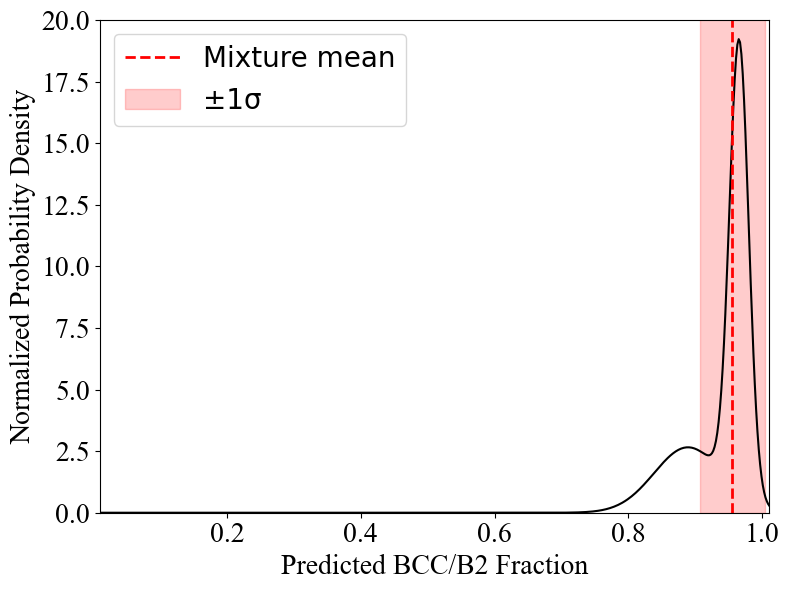

In [3]:
#This code plot Figure 5(a) of the manuscript

import torch
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
import logging
import matplotlib.pyplot as plt
from argparse import ArgumentParser
from torch.autograd import Variable
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.distributions import Normal, OneHotCategorical
import torch.nn.utils as nn_utils

torch.manual_seed(123456)
np.random.seed(123456)


def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0.0)        
class MDN(nn.Module):
    def __init__(self, n_hidden, n_gaussians,n_hidden_layers,bn, dout, dout_value):
        super(MDN, self).__init__()       
        layers = [nn.Linear(41, n_hidden), nn.Tanh()] 
        if bn == 1:
            layers.append(nn.BatchNorm1d(n_hidden))    
        for _ in range(n_hidden_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())
        if dout==1:
            layers.append(nn.Dropout(dout_value))
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())   
        else:
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())       
        self.z_h = nn.Sequential(*layers)             
        self.z_pi = nn.Linear(n_hidden, n_gaussians)
        self.z_sigma = nn.Linear(n_hidden, n_gaussians)
        self.z_mu = nn.Linear(n_hidden, n_gaussians)  
    def forward(self, x):
        z_h = self.z_h(x)
        pi = nn.functional.softmax(self.z_pi(z_h), -1)
        sigma = torch.exp(self.z_sigma(z_h))+ 1e-8
        sigma = torch.clamp(sigma, min=1e-4)
        mu = 0 + (1 - 0) * (torch.tanh(self.z_mu(z_h)) + 1) / 2
        return pi, sigma, mu    

def gaussian_pdf(y, mu, sigma):
    oneDivSqrtTwoPI = 1.0 / np.sqrt(2.0 * np.pi)
    exponent = -0.5 * ((y - mu) / sigma) ** 2
    return oneDivSqrtTwoPI * torch.exp(exponent) / sigma
def mixture_density(y, pi, mu, sigma):
    K = pi.size(1)  
    mixture_pdf = torch.zeros_like(y)  
    for k in range(K):
        gaussian_k = gaussian_pdf(y, mu[:, k], sigma[:, k])
        mixture_pdf += pi[:, k] * gaussian_k
    return mixture_pdf


model = MDN(n_hidden=83, n_gaussians=4,n_hidden_layers=7,bn=0, dout=0, dout_value=0.35831) #BCC
model.eval()
optimizer = optim.Adam(model.parameters(), lr=0.00007)
PATH = "checkpoint/model-806.pt" 
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
plt.figure(figsize=(8, 6))
nsmp=48049 #Chosen sample
data_x = np.load('xlo_test.npy')[[nsmp],:] 
comp=np.load('xlo_test_comp.npy')[nsmp,:]
data_y = np.load('ylo_test.npy')[[nsmp],:]
data_y[:,1]=data_y[:,1]+data_y[:,3]
T=data_x[:,-1]*(1892-850)+850
data_x_np = torch.tensor(data_x, dtype=torch.float)
pi, sigma, mu = model(data_x_np)

print('comp=',comp)
print('T (K)=',T)
print('data_y[1]=',data_y[:,1])

weighted_average_mu = torch.sum(pi * mu, dim=-1)
weighted_sigma = torch.sqrt(torch.sum(pi * (sigma ** 2 + (mu - weighted_average_mu.unsqueeze(-1)) ** 2), dim=-1))
weighted_average_mu_np = weighted_average_mu.detach().numpy()
weighted_sigma_np = weighted_sigma.detach().numpy()
y_values = torch.linspace(0, 2, 1000).unsqueeze(1)  
mixture_pdf = mixture_density(y_values, pi, mu, sigma)
area = torch.trapz(mixture_pdf.squeeze(), y_values.squeeze()) 
mixture_pdf = mixture_pdf / area 
plt.plot(y_values.squeeze(), mixture_pdf.squeeze().detach().numpy(),color='k')
plt.axvline(weighted_average_mu_np, color='red', linestyle='--', linewidth=2, label='Mixture mean')
plt.fill_betweenx(
    [0, plt.ylim()[1]],
    weighted_average_mu_np - weighted_sigma_np,
    weighted_average_mu_np + weighted_sigma_np,
    color='red', alpha=0.2, label='±1σ'
)

print('Mu=',weighted_average_mu_np)
print('Sigma=',weighted_sigma_np)
plt.xlabel("Predicted BCC Fraction",fontsize=20, fontname='Times New Roman')
plt.ylabel("Normalized Probability Density",fontsize=20, fontname='Times New Roman')
plt.xticks(fontsize=20, fontname='Times New Roman')
plt.yticks(fontsize=20, fontname='Times New Roman') 
plt.xlim([0.01,1.01])
plt.ylim([0,20])
plt.legend(fontsize=20,prop={'family': 'Times New Roman'})
plt.tight_layout()
plt.savefig('5a.png', dpi=600)

comp= [0.32 0.   0.26 0.19 0.   0.11 0.   0.   0.12]
T (K)= [947.]
data_y[1]= [0.91]
Mu (All)= [0.95563537]
Sigma (All)= [0.04902706]
Mu (5)= [0.70858157]
Sigma (5)= [0.17629251]


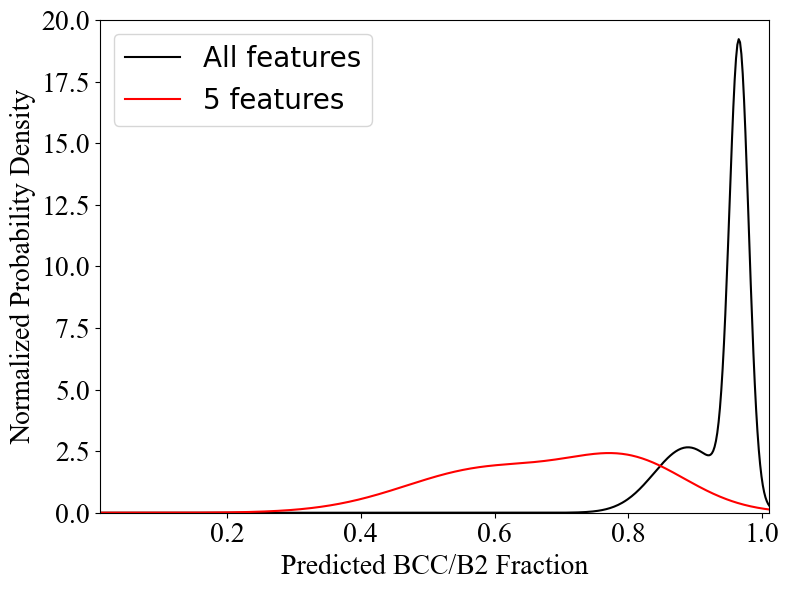

In [4]:
#This code plot Figure 5(b) of the manuscript

import torch
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
import logging
import matplotlib.pyplot as plt
from argparse import ArgumentParser
from torch.autograd import Variable
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.distributions import Normal, OneHotCategorical
import torch.nn.utils as nn_utils

torch.manual_seed(123456)
np.random.seed(123456)


def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0.0)        
class MDN(nn.Module):
    def __init__(self, n_hidden, n_gaussians,n_hidden_layers,bn, dout, dout_value):
        super(MDN, self).__init__()       
        layers = [nn.Linear(41, n_hidden), nn.Tanh()] 
        if bn == 1:
            layers.append(nn.BatchNorm1d(n_hidden))    
        for _ in range(n_hidden_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())
        if dout==1:
            layers.append(nn.Dropout(dout_value))
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())   
        else:
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())       
        self.z_h = nn.Sequential(*layers)             
        self.z_pi = nn.Linear(n_hidden, n_gaussians)
        self.z_sigma = nn.Linear(n_hidden, n_gaussians)
        self.z_mu = nn.Linear(n_hidden, n_gaussians)  
    def forward(self, x):
        z_h = self.z_h(x)
        pi = nn.functional.softmax(self.z_pi(z_h), -1)
        sigma = torch.exp(self.z_sigma(z_h))+ 1e-8
        sigma = torch.clamp(sigma, min=1e-4)
        mu = 0 + (1 - 0) * (torch.tanh(self.z_mu(z_h)) + 1) / 2
        return pi, sigma, mu     
class MDN1(nn.Module):
    def __init__(self, n_hidden, n_gaussians,n_hidden_layers,bn, dout, dout_value):
        super(MDN1, self).__init__()       
        layers = [nn.Linear(5, n_hidden), nn.Tanh()] 
        if bn == 1:
            layers.append(nn.BatchNorm1d(n_hidden))    
        for _ in range(n_hidden_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())
        if dout==1:
            layers.append(nn.Dropout(dout_value))
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())   
        else:
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())       
        self.z_h = nn.Sequential(*layers)             
        self.z_pi = nn.Linear(n_hidden, n_gaussians)
        self.z_sigma = nn.Linear(n_hidden, n_gaussians)
        self.z_mu = nn.Linear(n_hidden, n_gaussians)  
    def forward(self, x):
        z_h = self.z_h(x)
        pi = nn.functional.softmax(self.z_pi(z_h), -1)
        sigma = torch.exp(self.z_sigma(z_h))+ 1e-8
        sigma = torch.clamp(sigma, min=1e-4)
        mu = 0 + (1 - 0) * (torch.tanh(self.z_mu(z_h)) + 1) / 2
        return pi, sigma, mu      
def gaussian_pdf(y, mu, sigma):
    oneDivSqrtTwoPI = 1.0 / np.sqrt(2.0 * np.pi)
    exponent = -0.5 * ((y - mu) / sigma) ** 2
    return oneDivSqrtTwoPI * torch.exp(exponent) / sigma
def mixture_density(y, pi, mu, sigma):
    K = pi.size(1)  
    mixture_pdf = torch.zeros_like(y)  
    for k in range(K):
        gaussian_k = gaussian_pdf(y, mu[:, k], sigma[:, k])
        mixture_pdf += pi[:, k] * gaussian_k
    return mixture_pdf


model = MDN(n_hidden=83, n_gaussians=4,n_hidden_layers=7,bn=0, dout=0, dout_value=0.35831) #BCC
model.eval()
optimizer = optim.Adam(model.parameters(), lr=0.00007)
PATH = "checkpoint/model-806_bcc.pt" 
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
plt.figure(figsize=(8, 6))
nsmp=48049 #Chosen sample
data_x = np.load('xlo_test.npy')[[nsmp],:] 
comp=np.load('xlo_test_comp.npy')[nsmp,:]
data_y = np.load('ylo_test.npy')[[nsmp],:]
data_y[:,1]=data_y[:,1]+data_y[:,3]
T=data_x[:,-1]*(1892-850)+850
data_x_np = torch.tensor(data_x, dtype=torch.float)
pi, sigma, mu = model(data_x_np)

print('comp=',comp)
print('T (K)=',T)
print('data_y[1]=',data_y[:,1])

weighted_average_mu = torch.sum(pi * mu, dim=-1)
weighted_sigma = torch.sqrt(torch.sum(pi * (sigma ** 2 + (mu - weighted_average_mu.unsqueeze(-1)) ** 2), dim=-1))
weighted_average_mu_np = weighted_average_mu.detach().numpy()
weighted_sigma_np = weighted_sigma.detach().numpy()
print('Mu (All)=',weighted_average_mu_np)
print('Sigma (All)=',weighted_sigma_np)
y_values = torch.linspace(0, 2, 1000).unsqueeze(1)  
mixture_pdf = mixture_density(y_values, pi, mu, sigma)
area = torch.trapz(mixture_pdf.squeeze(), y_values.squeeze()) 
mixture_pdf = mixture_pdf / area 
plt.plot(y_values.squeeze(), mixture_pdf.squeeze().detach().numpy(),color='k',label='All features')

data_x = np.load('xlo_test.npy')[[nsmp],[28,31,32,2,6]] 
comp=np.load('xlo_test_comp.npy')[nsmp,:]
data_y = np.load('ylo_test.npy')[[nsmp],:]
data_y[:,1]=data_y[:,1]+data_y[:,3]
data_x_np = torch.tensor(data_x, dtype=torch.float)
model1 = MDN1(n_hidden=83, n_gaussians=4,n_hidden_layers=7,bn=0, dout=0, dout_value=0.35831) #BCC
model1.eval()
optimizer = optim.Adam(model1.parameters(), lr=0.00007)
PATH = "checkpoint/model-642_bcc_5feat.pt" 
checkpoint = torch.load(PATH)
model1.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
pi, sigma, mu = model1(data_x_np)
pi=pi.reshape(1,pi.shape[0]) 
sigma=sigma.reshape(1,sigma.shape[0])
mu=mu.reshape(1,mu.shape[0])
weighted_average_mu = torch.sum(pi * mu, dim=-1)
weighted_sigma = torch.sqrt(torch.sum(pi * (sigma ** 2 + (mu - weighted_average_mu.unsqueeze(-1)) ** 2), dim=-1))
weighted_average_mu_np = weighted_average_mu.detach().numpy()
weighted_sigma_np = weighted_sigma.detach().numpy()
print('Mu (5)=',weighted_average_mu_np)
print('Sigma (5)=',weighted_sigma_np)
y_values = torch.linspace(0, 2, 1000).unsqueeze(1)  
mixture_pdf = mixture_density(y_values, pi, mu, sigma)
area = torch.trapz(mixture_pdf.squeeze(), y_values.squeeze())
mixture_pdf = mixture_pdf / area
plt.plot(y_values.squeeze(), mixture_pdf.squeeze().detach().numpy(),color='r',label='5 features')

plt.xlabel("Predicted BCC Fraction",fontsize=20, fontname='Times New Roman')
plt.ylabel("Normalized Probability Density",fontsize=20, fontname='Times New Roman')
plt.xticks(fontsize=20, fontname='Times New Roman')
plt.yticks(fontsize=20, fontname='Times New Roman') 
plt.xlim([0.01,1.01])
plt.ylim([0,20])
plt.legend(fontsize=20,prop={'family': 'Times New Roman'})
plt.tight_layout()
plt.savefig('5b.png', dpi=600)

Baseline Log-Likelihood: tensor([1.1626, 0.9715, 2.8536,  ..., 2.9746, 2.7100, 3.1274])
Feature Importance Ranking (Most Important to Least):
[ 2 32 28  6 31 30  1 14 29 20 34 21 40 22 35 18 36 25 38  7 33 37 19 27
 16 23  8 24 17  4 39 26 13  5 11  9 10  0 15  3 12]


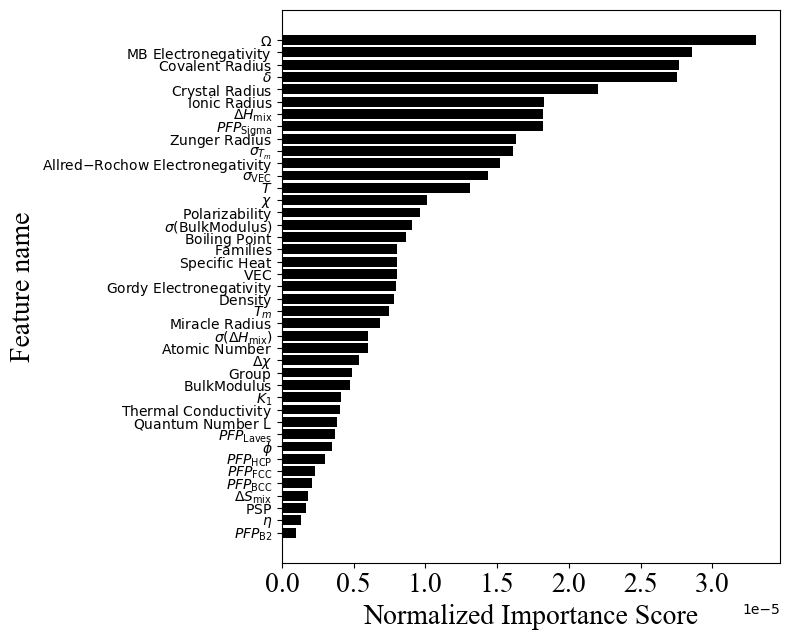

In [16]:
#This code generates Figure 7(a) of the manuscript

import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(123456)
np.random.seed(123456)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0.0)        
class MDN(nn.Module):
    def __init__(self, n_hidden, n_gaussians,n_hidden_layers,bn, dout, dout_value):
        super(MDN, self).__init__()
        layers = [nn.Linear(41, n_hidden), nn.Tanh()] 
        if bn == 1:
            layers.append(nn.BatchNorm1d(n_hidden))    
        for _ in range(n_hidden_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())
        if dout==1:
            layers.append(nn.Dropout(dout_value))
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())   
        else:
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())       
        self.z_h = nn.Sequential(*layers)
        self.z_pi = nn.Linear(n_hidden, n_gaussians)
        self.z_sigma = nn.Linear(n_hidden, n_gaussians)
        self.z_mu = nn.Linear(n_hidden, n_gaussians)  
    def forward(self, x):
        z_h = self.z_h(x)
        pi = nn.functional.softmax(self.z_pi(z_h), -1)
        sigma = torch.exp(self.z_sigma(z_h))+ 1e-8
        sigma = torch.clamp(sigma, min=1e-4)
        mu = 0 + (1 - 0) * (torch.tanh(self.z_mu(z_h)) + 1) / 2
        return pi, sigma, mu
oneDivSqrtTwoPI = 1.0 / np.sqrt(2.0*np.pi) 
def gaussian_distribution(y, mu, sigma):
    result = (y.expand_as(mu) - mu) * torch.reciprocal(sigma)
    result = -0.5 * (result * result)
    return (torch.exp(result) * torch.reciprocal(sigma)) * oneDivSqrtTwoPI
def mdn_loss_fn(pi, sigma, mu, y):
    result = gaussian_distribution(y, mu, sigma) * pi
    result1 = torch.sum(result, dim=1)
    result2 = -torch.log(result1+1e-12)
    return result2
def compute_log_likelihood(mdn_model, data_loader, device):
    mdn_model.eval()
    total_log_likelihood = 0.0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            pi, sigma, mu = mdn_model(x)
            loss = mdn_loss_fn(pi, sigma, mu, y)
    return -loss 
def feature_importance_perturbation(mdn_model, data_loader, device, perturbation_std=0.05):
    baseline_log_likelihood = compute_log_likelihood(mdn_model, data_loader, device)
    print(f"Baseline Log-Likelihood: {baseline_log_likelihood}")
    num_features = data_loader.dataset[0][0].shape[0]
    importance_scores = np.zeros(num_features)
    for feature_idx in range(num_features):
        perturbed_log_likelihood = 0.0 
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            perturbed_x = x.clone()
            noise = torch.normal(0, perturbation_std, size=(x.size(0),), device=device)
            perturbed_x[:, feature_idx] += noise  
            perturbed_x[:, feature_idx] = torch.clamp(perturbed_x[:, feature_idx], min=0.0, max=1.0)
            pi, sigma, mu = mdn_model(perturbed_x)
            loss = mdn_loss_fn(pi, sigma, mu, y)        
            perturbed_log_likelihood =-loss
            importance_scores[feature_idx] = torch.mean(torch.abs(baseline_log_likelihood - perturbed_log_likelihood))        
    return importance_scores 
X_test=np.load('xlo_test.npy')[:,:]
y_test=np.load('ylo_test.npy')[:,:] #bug fixed 
y_test[:,1]=y_test[:,1]+y_test[:,3]
phs=1 #phase (bcc = 1)
y_test=y_test[:,phs:phs+1]
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=X_test.shape[0], shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MDN(n_hidden=83, n_gaussians=4,n_hidden_layers=7,bn=0, dout=0, dout_value=0.35831) #BCC
model.eval()
optimizer = optim.Adam(model.parameters(), lr=0.00007)
PATH = "checkpoint/model-806_bcc.pt" 
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
feature_importance_scores = feature_importance_perturbation(model, test_loader, device)
feature_ranking = np.argsort(np.abs(feature_importance_scores))[::-1]
print("Feature Importance Ranking (Most Important to Least):")
print(feature_ranking)  
feature_names = [
    r"$\Delta S_{\mathrm{mix}}$", r"$\Delta H_{\mathrm{mix}}$", r"$\Omega$", r"$\eta$", r"$K_1$", r"$\phi$", r"$\delta$",
    r"$\mathrm{VEC}$", r"$\Delta \chi$", r"$PFP_{\mathrm{FCC}}$", r"$PFP_{\mathrm{BCC}}$", r"$PFP_{\mathrm{HCP}}$", r"$PFP_{\mathrm{B2}}$",
    r"$PFP_{\mathrm{Laves}}$", r"$PFP_{\mathrm{Sigma}}$", r"$\mathrm{PSP}$", r"$\sigma(\Delta H_{\mathrm{mix}})$", r"$\mathrm{BulkModulus}$",
    r"$\sigma(\mathrm{BulkModulus})$", r"$T_m$", r"$\sigma_{T_m}$", r"$\sigma_{\mathrm{VEC}}$", r"$\chi$", r"$\mathrm{Atomic\ Number}$",
    r"$\mathrm{Group}$", r"$\mathrm{Families}$", r"$\mathrm{Quantum\ Number\ L}$", r"$\mathrm{Miracle\ Radius}$", r"$\mathrm{Covalent\ Radius}$", r"$\mathrm{Zunger\ Radius}$",
    r"$\mathrm{Ionic\ Radius}$", r"$\mathrm{Crystal\ Radius}$", r"$\mathrm{MB\ Electronegativity}$", r"$\mathrm{Gordy\ Electronegativity}$", r"$\mathrm{Allred{-}Rochow\ Electronegativity}$",
    r"$\mathrm{Polarizability}$", r"$\mathrm{Boiling\ Point}$", r"$\mathrm{Density}$", r"$\mathrm{Specific\ Heat}$", r"$\mathrm{Thermal\ Conductivity}$",
    r"$T$"
]
num_data_points=X_test.shape[0]
normalized_scores = [score / num_data_points for score in feature_importance_scores]
features = [f"{i}" for i in range(len(feature_importance_scores))]
sorted_indices = np.argsort(normalized_scores)[::-1]
sorted_features = [feature_names[i] for i in sorted_indices]
sorted_scores = [normalized_scores[i] for i in sorted_indices]
plt.figure(figsize=(8, 6.5))
plt.barh(sorted_features, sorted_scores, color="black")
plt.xlabel("Normalized Importance Score",fontsize=20, fontname='Times New Roman')
plt.ylabel("Feature name",fontsize=20, fontname='Times New Roman')
plt.gca().invert_yaxis()  
plt.xticks(fontsize=20, fontname='Times New Roman')
plt.yticks(fontsize=10, fontname='Times New Roman') 
plt.tight_layout()
plt.savefig('6a.png', dpi=600)

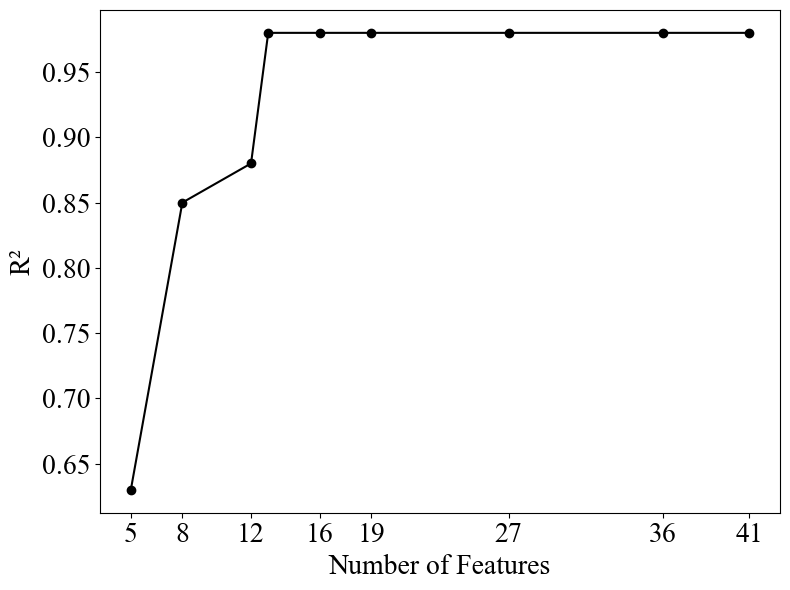

In [9]:
#This code generates Figure 7(d) of the manuscript
import numpy as np
import matplotlib.pyplot as plt

n=[5,8,12,13,16,19,27,36,41]
#R2=[0.63,0.85,0.98,0.98,0.98,0.98,0.98,0.98,0.98]
R2=[0.63,0.85,0.88,0.98,0.98,0.98,0.98,0.98,0.98]
plt.figure(figsize=(8, 6))
plt.xlabel('Number of Features',fontsize=20, fontname='Times New Roman')
plt.ylabel('R²',fontsize=20, fontname='Times New Roman')
plt.scatter(n,R2,color='black')
plt.plot(n,R2,color='black')

plt.xticks([5,8,12,16,19,27,36,41],fontsize=20, fontname='Times New Roman')
plt.yticks(fontsize=20, fontname='Times New Roman')
plt.tight_layout()
plt.savefig('6d.png', dpi=600)

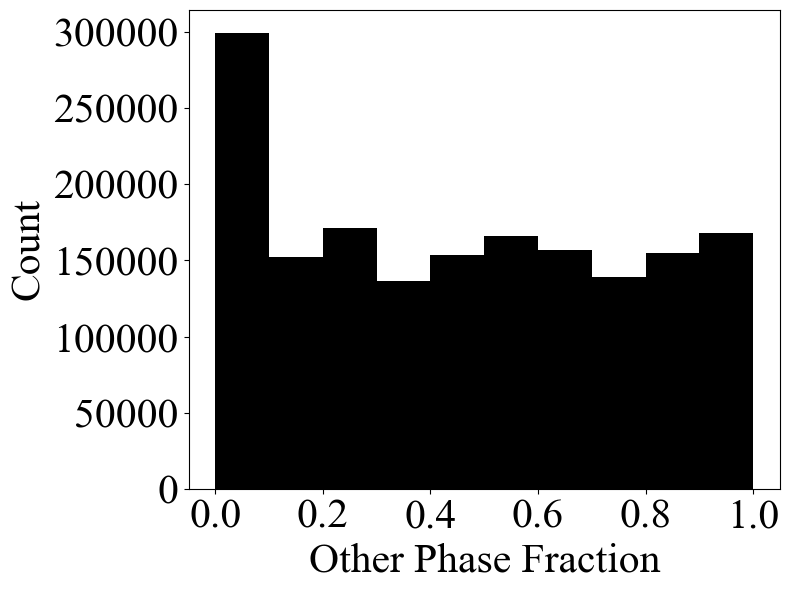

In [12]:
#This code generates Figure 1 and S1.
import numpy as np
import matplotlib.pyplot as plt

A=np.load('ylo_oversampling.npy')
#A[:,1]=A[:,1]+A[:,3]
#A[:,7]=A[:,7]+A[:,2]

bin_range = (0, 1)
bin_size = 0.1
num_bins = int((bin_range[1] - bin_range[0]) / bin_size)
bins = np.arange(bin_range[0], bin_range[1] + bin_size, bin_size)



plt.figure(figsize=(8, 6))
plt.hist(A[:,0],color='black') #phase
plt.xlabel('Other Phase Fraction',fontsize=30, fontname='Times New Roman')
plt.ylabel('Count',fontsize=30, fontname='Times New Roman')
#plt.xlim([0,1])
#plt.ylim([-0.1,1.1])
plt.xticks(fontsize=30, fontname='Times New Roman')
plt.yticks(fontsize=30, fontname='Times New Roman') 
plt.tight_layout()
plt.savefig('1Sf.png', dpi=600)

In [33]:
#Revision: This code separate the aleatoric and epistemic uncertainty

import numpy as np
import torch
import torch.optim as optim
import logging
import matplotlib.pyplot as plt
from argparse import ArgumentParser
from torch.autograd import Variable
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.distributions import Normal, OneHotCategorical
import torch.nn.utils as nn_utils
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(123456)
np.random.seed(123456)


def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0.0)        
class MDN(nn.Module):
    def __init__(self, n_hidden, n_gaussians,n_hidden_layers,bn, dout, dout_value):
        super(MDN, self).__init__()                
        layers = [nn.Linear(13, n_hidden), nn.Tanh()] # 41 = Input features
        if bn == 1:
            layers.append(nn.BatchNorm1d(n_hidden))    
        for _ in range(n_hidden_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())
        if dout==1:
            layers.append(nn.Dropout(dout_value))
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())   
        else:
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())       
        self.z_h = nn.Sequential(*layers)                        
        self.z_pi = nn.Linear(n_hidden, n_gaussians)
        self.z_sigma = nn.Linear(n_hidden, n_gaussians)
        self.z_mu = nn.Linear(n_hidden, n_gaussians)  
    def forward(self, x):
        z_h = self.z_h(x)
        pi = nn.functional.softmax(self.z_pi(z_h), -1)
        sigma = torch.exp(self.z_sigma(z_h))+ 1e-8
        sigma = torch.clamp(sigma, min=1e-4)
        mu = 0 + (1 - 0) * (torch.tanh(self.z_mu(z_h)) + 1) / 2
        return pi, sigma, mu    
oneDivSqrtTwoPI = 1.0 / np.sqrt(2.0*np.pi) 
def gaussian_distribution(y, mu, sigma):
    result = (y.expand_as(mu) - mu) * torch.reciprocal(sigma)
    result = -0.5 * (result * result)
    return (torch.exp(result) * torch.reciprocal(sigma)) * oneDivSqrtTwoPI
def mdn_loss_fn(pi, sigma, mu, y):
    result = gaussian_distribution(y, mu, sigma) * pi
    result1 = torch.sum(result, dim=1)
    result2 = -torch.log(result1+1e-12)
    return torch.mean(result2)


checkpoints = [
    "checkpoint/model-720_bcc_13feat.pt",
    "checkpoint/model-780_bcc_13feat.pt",
    "checkpoint/model-694_bcc_13feat.pt"
]

mus_all = []
vars_all = []
data_x = np.load('xlo_test.npy')[:,[2,32,28,6,31,30,1,14,29,20,34,21,40]]
data_y = np.load('ylo_test.npy')
phs=1 
data_y[:,1]=data_y[:,1]+data_y[:,3] 
data_x_np = torch.tensor(data_x, dtype=torch.float)
data_y_np = torch.tensor(data_y, dtype=torch.float)[:,phs:phs+1]  
for PATH in checkpoints:
    model = MDN(n_hidden=83, n_gaussians=4, n_hidden_layers=7, bn=0, dout=0, dout_value=0.35831)
    model.eval()
    checkpoint = torch.load(PATH)
    model.load_state_dict(checkpoint['model_state_dict'])
    with torch.no_grad():
        pi, sigma, mu = model(data_x_np)
        mu_model = torch.sum(pi * mu, dim=-1)
        var_model = torch.sum(
            pi * (sigma**2 + (mu - mu_model.unsqueeze(-1))**2),
            dim=-1
        )

        mus_all.append(mu_model)
        vars_all.append(var_model)
mus_all = torch.stack(mus_all)     
vars_all = torch.stack(vars_all)  
aleatoric = torch.mean(vars_all, dim=0)
epistemic = torch.var(mus_all, dim=0, unbiased=True)
total_var = aleatoric + epistemic
mu_ensemble = torch.mean(mus_all, dim=0)
sigma_total = torch.sqrt(total_var)
sigma_aleatoric = torch.sqrt(aleatoric)
sigma_epistemic = torch.sqrt(epistemic)
mean_aleatoric = torch.mean(sigma_aleatoric)
mean_epistemic = torch.mean(sigma_epistemic)
print('mean_aleatoric=',mean_aleatoric)
print('mean_epistemic=',mean_epistemic)

mean_aleatoric= tensor(0.0304)
mean_epistemic= tensor(0.0189)
